# **DualStreamNetV2 (Spatial + FFT, CBAM attention, Cross-Stream Fusion)**

В этой версии архитектура стала значительно тяжелее и сложнее, поэтому сразу стоит отметить, что для полноценного обучения и инференса этой модели строго необходима видеокарта уровня NVIDIA A100. Это обусловлено не только объемом параметров, но и специфическими оптимизациями под bfloat16 и интенсивными вычислениями FFT прямо на GPU. Сразу уточню, что в текущем пайплайне был обучен только первый конфиг из списка ансамбля, так что на остальные конфигурации можно не обращать внимания. Код максимально плотный, местами нечеловеческий и оптимизирован под экстремальную производительность в ущерб читаемости.

Основой архитектуры является DualStreamNetV2, которая параллельно обрабатывает пространственные данные (RGB) и частотные характеристики (FFT). В отличие от предыдущих итераций, здесь используются двойные остаточные блоки (Double ResBlocks) и продвинутый механизм Cross-Stream Fusion, который позволяет потокам обмениваться информацией на нескольких уровнях глубины через обучаемые коэффициенты гейтирования. В каждую ветку интегрированы модули внимания CBAM, работающие как с каналами, так и с пространственными сетками. Частотный поток обрабатывает амплитудный спектр, вычисляемый батчами на видеокарте, что критически ускоряет обучение по сравнению с подготовкой данных на CPU. Финальный классификатор представляет собой глубокий MLP с использованием Batch Normalization и Dropout для стабилизации предсказаний.

Ниже представлена структурная схема этой системы:

```text
          Входное изображение [B, 3, 256, 256]
                         │
        ┌────────────────┴────────────────┐
        │                                 │
   Spatial Stream (RGB)          Frequency Stream (FFT)
        │                                 │
   Conv 7x7 + BN + ReLU          Conv 7x7 + BN + ReLU
        │                                 │
   Double ResBlock + CBAM        Double ResBlock + CBAM
        │                                 │
        ├─────── Cross-Stream Fusion 1 ───┤
        │                                 │
   Double ResBlock + CBAM        Double ResBlock + CBAM
        │                                 │
        ├─────── Cross-Stream Fusion 2 ───┤
        │                                 │
   Double ResBlock + CBAM        Double ResBlock + CBAM
        │                                 │
        └───────┬────────────────┬────────┘
                │                │
          Global Pool      Global Pool
                │                │
                └───────┬────────┘
                        │
                Concat [Feat_1, Feat_2]
                        │
             MLP (512 -> 128 -> 1)
                        │
                Sigmoid / Logit
```

Модель поддерживает стохастическое усреднение весов (SWA) для улучшения обобщающей способности и использует технику Test-Time Augmentation (TTA) при инференсе. Обучение проходит с использованием смешанной точности (AMP) в формате bfloat16, что позволяет эффективно утилизировать тензорные ядра A100. Система также включает динамический поиск порога классификации на валидационной выборке для достижения максимального F1-score. Все утилиты, включая CutMix и специфические функции нормализации спектра, перенесены на GPU для минимизации задержек при передаче данных.


### Инструкция:
1. Загрузи в **корень Google Drive** файлы: `train_images.zip`, `test_images.zip`, `train_solution.csv`
2. Запусти все ячейки по порядку (Runtime -> Run all)
3. Чекпоинты сохраняются на Drive — если Colab отключится, прогресс не потеряется
4. Скачай `submission.csv` в конце

# монтирование гугл драйв, копирование данных на локальное хранилище

In [ ]:
# Cell 1: Mount Google Drive, copy zips locally, then unzip
import os, zipfile, shutil

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DRIVE = "/content/drive/MyDrive"

def count_jpgs(path):
    if not os.path.exists(path): return 0
    return len([f for f in os.listdir(path) if f.endswith('.jpg')])

for zf, img_dir in [("train_images.zip", "/content/train_images"),
                     ("test_images.zip", "/content/test_images")]:
    if count_jpgs(img_dir) > 0:
        print(f"  {img_dir}: {count_jpgs(img_dir)} images, skip")
        continue

    src = os.path.join(DRIVE, zf)
    local_zip = f"/content/{zf}"

    # Step 1: copy zip from Drive to local (avoids Transport endpoint errors)
    if not os.path.exists(local_zip):
        print(f"  Copying {zf} from Drive to local disk...")
        shutil.copy2(src, local_zip)
        print(f"  Copied! ({os.path.getsize(local_zip) / 1e9:.1f} GB)")

    # Step 2: unzip from local disk (fast)
    print(f"  Unzipping {zf}...")
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall("/content")
    print(f"  Done! {count_jpgs(img_dir)} images")

    # Clean up local zip to save disk space
    os.remove(local_zip)

# CSV
csv_dst = "/content/train_solution.csv"
if not os.path.exists(csv_dst):
    shutil.copy2(os.path.join(DRIVE, "train_solution.csv"), csv_dst)

print(f"\nTrain: {count_jpgs('/content/train_images')} images")
print(f"Test:  {count_jpgs('/content/test_images')} images")
print(f"CSV:   {os.path.exists(csv_dst)}")

!pip install -q scikit-learn tqdm

Mounted at /content/drive
  Copying train_images.zip from Drive to local disk...
  Copied! (2.2 GB)
  Unzipping train_images.zip...
  Done! 50000 images
  Copying test_images.zip from Drive to local disk...
  Copied! (0.4 GB)
  Unzipping test_images.zip...
  Done! 10000 images

Train: 50000 images
Test:  10000 images
CSV:   True


# Импорты и конфиг

In [ ]:
# Cell 2: Imports & Config [A100 40GB — final]
import random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.swa_utils import AveragedModel, SWALR
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

class Config:
    TRAIN_IMG_DIR = "/content/train_images"
    TEST_IMG_DIR = "/content/test_images"
    LABELS_CSV = "/content/train_solution.csv"
    CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints_v2"
    SUBMISSION_PATH = "/content/drive/MyDrive/submission.csv"

    CHANNELS = [48, 96, 192, 256, 384]
    DROPOUT = 0.3
    DOUBLE_BLOCKS = True

    BATCH_SIZE = 64       # 48 used 18GB forward -> 64 should use ~24GB forward, ~38GB training
    NUM_EPOCHS = 80
    LR = 5e-4             # scaled for batch 64
    WEIGHT_DECAY = 5e-4
    GRAD_CLIP = 5.0
    ADAM_BETA1 = 0.9

    LABEL_SMOOTHING = 0.05
    CUTMIX_PROB = 0.5
    CUTMIX_ALPHA = 1.0

    COSINE_T0 = 15
    COSINE_T_MULT = 2
    COSINE_ETA_MIN = 1e-6
    WARMUP_EPOCHS = 5

    USE_SWA = True
    SWA_LR = 1e-4
    SWA_EPOCHS = 15

    PATIENCE = 15
    MIN_DELTA = 0.001
    VAL_SPLIT = 0.15
    NUM_WORKERS = 4
    SEED = 42
    FFT_STATS_N = 2000

    USE_AMP = True
    AMP_DTYPE = 'bfloat16'

    THRESH_STEP = 0.005
    THRESH_MIN = 0.15
    THRESH_MAX = 0.85

    ENSEMBLE = [
        {'seed': 42,   'freq': 'fft_mag',   'aug': 'default',    'ch': [48,96,192,256,384]},
        {'seed': 137,  'freq': 'fft_mag',   'aug': 'heavy',      'ch': [48,96,192,256,384]},
        {'seed': 2024, 'freq': 'fft_phase', 'aug': 'default',    'ch': [48,96,192,256,384]},
        {'seed': 777,  'freq': 'fft_mag',   'aug': 'default',    'ch': [48,96,192,256,384]},
        {'seed': 314,  'freq': 'fft_mag',   'aug': 'multiscale', 'ch': [48,96,192,256,384]},
    ]

os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    gp = torch.cuda.get_device_properties(0)
    print(f"GPU: {gp.name}, VRAM: {gp.total_memory/1e9:.0f} GB")
print(f"Batch: {Config.BATCH_SIZE}, Double blocks: {Config.DOUBLE_BLOCKS}, AMP: {Config.AMP_DTYPE}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB, VRAM: 42 GB
Batch: 64, Double blocks: True, AMP: bfloat16


# Утилиты

In [ ]:
# Cell 3: Utils [A100 optimized — bf16, GPU batch FFT, cudnn.benchmark]

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

class LabelSmoothingBCE(nn.Module):
    def __init__(self, s=0.05):
        super().__init__(); self.s = s
    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(logits, targets*(1-self.s) + (1-targets)*self.s)

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience, self.min_delta, self.counter, self.best = patience, min_delta, 0, None
    def __call__(self, score):
        if self.best is None: self.best = score; return False
        if score < self.best + self.min_delta: self.counter += 1; return self.counter >= self.patience
        self.best, self.counter = score, 0; return False

# --- Batched GPU FFT functions ---
def compute_fft_mag_batch(batch, mean=None, std=None):
    """[B,3,H,W] GPU tensor -> [B,3,H,W] FFT magnitude, all on GPU."""
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(batch), dim=(-2,-1))))
    if mean is not None and std is not None:
        return (lm - mean.unsqueeze(0)) / (std.clamp(min=0.01).unsqueeze(0) + 1e-8)
    return lm / 12.

def compute_fft_phase_batch(batch, mean=None, std=None):
    """[B,3,H,W] GPU tensor -> [B,6,H,W] FFT mag+phase, all on GPU."""
    fft = torch.fft.fftshift(torch.fft.fft2(batch), dim=(-2,-1))
    lm = torch.log1p(torch.abs(fft)); ph = torch.angle(fft) / torch.pi
    if mean is not None and std is not None:
        lm = (lm - mean.unsqueeze(0)) / (std.clamp(min=0.01).unsqueeze(0) + 1e-8)
    else:
        lm = lm / 12.
    return torch.cat([lm, ph], dim=1)

FREQ_BATCH = {'fft_mag': compute_fft_mag_batch, 'fft_phase': compute_fft_phase_batch}

def cutmix_data(spatial, freq, targets, alpha=1.0, freq_batch_func=None, fft_mean_gpu=None, fft_std_gpu=None):
    """CutMix on spatial, recompute FFT on GPU in batch (fast)."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(spatial.size(0), device=spatial.device)
    _, _, H, W = spatial.shape
    cr = np.sqrt(1.0 - lam)
    cw, ch = max(1,int(W*cr)), max(1,int(H*cr))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(0,cx-cw//2), max(0,cy-ch//2)
    x2,y2 = min(W,cx+cw//2), min(H,cy+ch//2)

    spatial = spatial.clone()
    spatial[:,:,y1:y2,x1:x2] = spatial[idx,:,y1:y2,x1:x2]

    # Recompute FFT on GPU in one batch call
    if freq_batch_func is not None:
        freq = freq_batch_func(spatial, fft_mean_gpu, fft_std_gpu)
    else:
        freq = freq.clone()
        freq[:,:,y1:y2,x1:x2] = freq[idx,:,y1:y2,x1:x2]

    lam = 1 - ((x2-x1)*(y2-y1)/(W*H))
    return spatial, freq, lam*targets + (1-lam)*targets[idx]

def calibrate_temperature(logits, labels):
    best_nll, best_t = float('inf'), 1.0
    for t in np.arange(0.5, 3.0, 0.05):
        p = 1./(1.+np.exp(-logits/t))
        nll = -np.mean(labels*np.log(p+1e-8) + (1-labels)*np.log(1-p+1e-8))
        if nll < best_nll: best_nll, best_t = nll, t
    return best_t

def find_best_threshold(probs, labels, step=0.005, lo=0.15, hi=0.85):
    best_f1, best_t = 0., 0.5
    for t in np.arange(lo, hi, step):
        f = f1_score(labels, (probs>t).astype(int), zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t, best_f1

@torch.no_grad()
def update_bn_dual(loader, model, device):
    momenta = {}
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            module.running_mean = torch.zeros_like(module.running_mean)
            module.running_var = torch.ones_like(module.running_var)
            momenta[module] = module.momentum
            module.momentum = None
            module.num_batches_tracked.zero_()
    model.train()
    for images, freq, labels in loader:
        model(images.to(device), freq.to(device))
    for module, mom in momenta.items():
        module.momentum = mom

print("Utils OK — GPU batch FFT, bf16 ready")

Utils OK — GPU batch FFT, bf16 ready


# Архитектура

In [ ]:
# Cell 4: Model — DualStreamNetV2 [A100: wider + double ResBlocks]

class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch//r, 8)
        self.fc = nn.Sequential(nn.Linear(ch, mid, bias=False), nn.ReLU(True), nn.Linear(mid, ch, bias=False))
    def forward(self, x):
        b, c = x.shape[:2]
        a = self.fc(F.adaptive_avg_pool2d(x,1).view(b,c))
        m = self.fc(F.adaptive_max_pool2d(x,1).view(b,c))
        return x * torch.sigmoid(a+m).view(b,c,1,1)

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(torch.cat([x.mean(1,keepdim=True), x.max(1,keepdim=True)[0]], 1)))

class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca, self.sa = ChannelAttention(ch, r), SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.c1 = nn.Conv2d(ic,oc,3,padding=1,bias=False); self.b1 = nn.BatchNorm2d(oc)
        self.c2 = nn.Conv2d(oc,oc,3,padding=1,bias=False); self.b2 = nn.BatchNorm2d(oc)
    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x)),True))),True)

class ResBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.conv = ConvBlock(ic, oc)
        self.skip = nn.Identity() if ic==oc else nn.Sequential(nn.Conv2d(ic,oc,1,bias=False), nn.BatchNorm2d(oc))
    def forward(self, x): return F.relu(self.conv(x) + self.skip(x), True)

class CrossFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gs = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
        self.gf = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
    def forward(self, s, f):
        sp, fp = F.adaptive_avg_pool2d(s,1).flatten(1), F.adaptive_avg_pool2d(f,1).flatten(1)
        c = torch.cat([sp,fp],1)
        gs, gf = self.gs(c).unsqueeze(-1).unsqueeze(-1), self.gf(c).unsqueeze(-1).unsqueeze(-1)
        return s*gs + f*(1-gs), f*gf + s*(1-gf)

def _make_stage_blocks(ic, oc, double=False):
    """Create ResBlock(s) + CBAM + Pool for one stage."""
    blocks = [ResBlock(ic, oc)]
    if double:
        blocks.append(ResBlock(oc, oc))  # second ResBlock (same channels)
    blocks.append(CBAM(oc))
    return nn.Sequential(*blocks), nn.MaxPool2d(2)

class DualStreamNetV2(nn.Module):
    def __init__(self, spatial_in=3, freq_in=3, channels=None, dropout=0.3, double_blocks=False):
        super().__init__()
        ch = channels or [64,128,256,384,512]
        db = double_blocks

        # Spatial stream
        self.ss = nn.Sequential(nn.Conv2d(spatial_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        s1_blocks = [ResBlock(ch[0],ch[0])];
        if db: s1_blocks.append(ResBlock(ch[0],ch[0]))
        s1_blocks += [CBAM(ch[0]), nn.MaxPool2d(2)]
        self.ss1 = nn.Sequential(*s1_blocks)
        self.ss2b, self.ss2p = _make_stage_blocks(ch[0],ch[1],db)
        self.ss3b, self.ss3p = _make_stage_blocks(ch[1],ch[2],db)
        self.ss4b, self.ss4p = _make_stage_blocks(ch[2],ch[3],db)
        s5_blocks = [ResBlock(ch[3],ch[4])];
        if db: s5_blocks.append(ResBlock(ch[4],ch[4]))
        s5_blocks.append(CBAM(ch[4]))
        self.ss5 = nn.Sequential(*s5_blocks)

        # Frequency stream (own weights)
        self.fs = nn.Sequential(nn.Conv2d(freq_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        f1_blocks = [ResBlock(ch[0],ch[0])];
        if db: f1_blocks.append(ResBlock(ch[0],ch[0]))
        f1_blocks += [CBAM(ch[0]), nn.MaxPool2d(2)]
        self.fs1 = nn.Sequential(*f1_blocks)
        self.fs2b, self.fs2p = _make_stage_blocks(ch[0],ch[1],db)
        self.fs3b, self.fs3p = _make_stage_blocks(ch[1],ch[2],db)
        self.fs4b, self.fs4p = _make_stage_blocks(ch[2],ch[3],db)
        f5_blocks = [ResBlock(ch[3],ch[4])];
        if db: f5_blocks.append(ResBlock(ch[4],ch[4]))
        f5_blocks.append(CBAM(ch[4]))
        self.fs5 = nn.Sequential(*f5_blocks)

        self.cf2, self.cf3, self.cf4 = CrossFusion(ch[1]), CrossFusion(ch[2]), CrossFusion(ch[3])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Linear(ch[4]*2,512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(512,128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(128,1))
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d,nn.BatchNorm1d)): nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias,0)

    def forward(self, si, fi):
        s, f = self.ss1(self.ss(si)), self.fs1(self.fs(fi))
        s, f = self.ss2b(s), self.fs2b(f); s, f = self.cf2(s,f); s, f = self.ss2p(s), self.fs2p(f)
        s, f = self.ss3b(s), self.fs3b(f); s, f = self.cf3(s,f); s, f = self.ss3p(s), self.fs3p(f)
        s, f = self.ss4b(s), self.fs4b(f); s, f = self.cf4(s,f); s, f = self.ss4p(s), self.fs4p(f)
        s, f = self.pool(self.ss5(s)).flatten(1), self.pool(self.fs5(f)).flatten(1)
        return self.clf(torch.cat([s,f],1))

# Quick test
m = DualStreamNetV2(channels=Config.CHANNELS, double_blocks=Config.DOUBLE_BLOCKS).to(device)
params = sum(p.numel() for p in m.parameters())
print(f"Model params: {params:,}")

# Estimate VRAM with batch
with torch.amp.autocast('cuda'):
    x = torch.randn(Config.BATCH_SIZE, 3, 256, 256, device=device)
    y = m(x, x)
    print(f"Forward pass OK, output: {y.shape}")
    allocated = torch.cuda.max_memory_allocated() / 1e9
    print(f"Peak VRAM: {allocated:.1f} GB")
del m, x, y; torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

Model params: 18,575,733
Forward pass OK, output: torch.Size([64, 1])
Peak VRAM: 23.2 GB


# Пайплайн данных

In [ ]:
# Cell 5: Data Pipeline

def compute_fft_mag(t, mean=None, std=None):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(t), dim=(-2,-1))))
    return (lm-mean)/(std.clamp(min=0.01)+1e-8) if mean is not None else lm/12.

def compute_fft_phase(t, mean=None, std=None):
    fft = torch.fft.fftshift(torch.fft.fft2(t), dim=(-2,-1))
    lm = torch.log1p(torch.abs(fft)); ph = torch.angle(fft)/torch.pi
    lm = (lm-mean)/(std.clamp(min=0.01)+1e-8) if mean is not None else lm/12.
    return torch.cat([lm, ph], 0)

FREQ = {'fft_mag': compute_fft_mag, 'fft_phase': compute_fft_phase}

def precompute_fft_stats(img_dir, csv_path, n=2000):
    df = pd.read_csv(csv_path, header=None, names=["id","label"])
    np.random.seed(Config.SEED)
    ids = np.random.choice(df["id"].values, min(n,len(df)), replace=False)
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([.5]*3,[.5]*3)])
    acc = []
    for i in tqdm(ids, desc="FFT stats", leave=False):
        try:
            img = tf(Image.open(os.path.join(img_dir, f"{i}.jpg")).convert("RGB"))
            acc.append(torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(img), dim=(-2,-1)))))
        except Exception:
            pass
    st = torch.stack(acc); return st.mean(0), st.std(0)

class FaceDS(Dataset):
    def __init__(self, ids, labels, img_dir, tf, freq_type, fm, fs):
        self.ids,self.labels,self.dir,self.tf = ids,labels,img_dir,tf
        self.ff,self.fm,self.fs = FREQ[freq_type],fm,fs
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            return img, self.ff(img,self.fm,self.fs), torch.tensor(self.labels[i], dtype=torch.float32)
        except Exception:
            return self.__getitem__(np.random.randint(len(self)))

class TestDS(Dataset):
    def __init__(self, img_dir, tf, freq_type, fm, fs):
        self.dir,self.tf = img_dir,tf
        self.ids = sorted(int(f.split('.')[0]) for f in os.listdir(img_dir) if f.endswith('.jpg'))
        self.ff,self.fm,self.fs = FREQ[freq_type],fm,fs
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            return self.ids[i], img, self.ff(img,self.fm,self.fs)
        except Exception:
            img = self.tf(Image.new("RGB", (256,256), (128,128,128)))
            return self.ids[i], img, self.ff(img,self.fm,self.fs)

def get_tf(aug='default', train=True):
    if not train: return transforms.Compose([transforms.ToTensor(), transforms.Normalize([.5]*3,[.5]*3)])
    b = [transforms.RandomHorizontalFlip(.5)]
    if aug=='heavy':
        b += [transforms.RandomVerticalFlip(.1),transforms.RandomRotation(15),
              transforms.RandomAffine(0,translate=(.08,.08)),transforms.ColorJitter(.3,.3,.2,.08)]
    elif aug=='multiscale':
        b += [transforms.RandomRotation(10),transforms.RandomResizedCrop(256,scale=(.75,1.),ratio=(.9,1.1)),
              transforms.ColorJitter(.2,.2,.15,.05)]
    else:
        b += [transforms.RandomRotation(10),transforms.RandomAffine(0,translate=(.05,.05)),
              transforms.ColorJitter(.2,.2,.15,.05)]
    b += [transforms.ToTensor(),transforms.Normalize([.5]*3,[.5]*3)]
    return transforms.Compose(b)

def make_loaders(freq_type, aug, fm, fs, seed):
    df = pd.read_csv(Config.LABELS_CSV, header=None, names=["id","label"])
    ids,labs = df["id"].values, df["label"].values
    tri,vi,trl,vl = train_test_split(ids,labs,test_size=Config.VAL_SPLIT,stratify=labs,random_state=seed)
    tds = FaceDS(tri,trl,Config.TRAIN_IMG_DIR,get_tf(aug,True),freq_type,fm,fs)
    vds = FaceDS(vi,vl,Config.TRAIN_IMG_DIR,get_tf('default',False),freq_type,fm,fs)
    sw = (1./np.bincount(trl))[trl]
    sampler = WeightedRandomSampler(torch.from_numpy(sw).double(), len(sw), replacement=True)
    tl = DataLoader(tds,Config.BATCH_SIZE,sampler=sampler,num_workers=Config.NUM_WORKERS,pin_memory=True,drop_last=True)
    vl_ = DataLoader(vds,Config.BATCH_SIZE,shuffle=False,num_workers=Config.NUM_WORKERS,pin_memory=True)
    return tl, vl_

print("Data pipeline OK — fftshift consistent everywhere")

Data pipeline OK — fftshift consistent everywhere


# Обучение

In [ ]:
# Cell 6: Training [A100 — bf16, TF32, GPU CutMix, no GradScaler]

def collect_preds(model, loader, dev):
    model.eval(); all_lo, all_la = [], []
    with torch.no_grad():
        for img, frq, lab in loader:
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                out = model(img.to(dev), frq.to(dev)).squeeze(1)
            all_lo.append(out.float())  # FIX: bf16 -> float32 for numpy compat
            all_la.append(lab)
    return torch.cat(all_lo).cpu().numpy(), torch.cat(all_la).numpy()

def train_one(idx, cfg, dev):
    seed, ft, aug, ch = cfg['seed'], cfg['freq'], cfg['aug'], cfg['ch']
    set_seed(seed)
    print(f"\n{'='*60}\nModel {idx+1}/5: seed={seed}, freq={ft}, aug={aug}, ch={ch}\n{'='*60}")

    # Enable TF32 for A100
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    fft_m, fft_s = precompute_fft_stats(Config.TRAIN_IMG_DIR, Config.LABELS_CSV, Config.FFT_STATS_N)
    tl, vl = make_loaders(ft, aug, fft_m, fft_s, seed)

    # FFT stats on GPU for fast CutMix recompute
    fft_m_gpu = fft_m.to(dev) if fft_m is not None else None
    fft_s_gpu = fft_s.to(dev) if fft_s is not None else None
    freq_batch_func = FREQ_BATCH[ft]

    fin = 6 if ft == 'fft_phase' else 3
    model = DualStreamNetV2(3, fin, ch, Config.DROPOUT, double_blocks=Config.DOUBLE_BLOCKS).to(dev)
    print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

    opt = torch.optim.AdamW(model.parameters(), lr=Config.LR, betas=(Config.ADAM_BETA1,.999), weight_decay=Config.WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, Config.COSINE_T0, Config.COSINE_T_MULT, Config.COSINE_ETA_MIN)
    crit = LabelSmoothingBCE(Config.LABEL_SMOOTHING)
    es = EarlyStopping(Config.PATIENCE, Config.MIN_DELTA)
    best_f1 = 0.
    ckpt = os.path.join(Config.CHECKPOINT_DIR, f"model_v2_{idx+1}.pth")

    # bf16 on A100: no GradScaler needed
    use_bf16 = (Config.AMP_DTYPE == 'bfloat16') if hasattr(Config, 'AMP_DTYPE') else False
    amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
    scaler = None if use_bf16 else torch.amp.GradScaler('cuda')

    for ep in range(Config.NUM_EPOCHS):
        if ep < Config.WARMUP_EPOCHS:
            for pg in opt.param_groups: pg['lr'] = Config.LR * (ep+1) / Config.WARMUP_EPOCHS
        else:
            sched.step(ep - Config.WARMUP_EPOCHS)

        model.train(); rl, nb = 0., 0
        for img, frq, lab in tqdm(tl, desc=f"Ep {ep+1}/{Config.NUM_EPOCHS}", leave=False):
            img,frq,lab = img.to(dev),frq.to(dev),lab.to(dev)
            if np.random.rand() < Config.CUTMIX_PROB:
                img,frq,lab = cutmix_data(img,frq,lab,Config.CUTMIX_ALPHA,
                                          freq_batch_func=freq_batch_func,
                                          fft_mean_gpu=fft_m_gpu, fft_std_gpu=fft_s_gpu)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', dtype=amp_dtype):
                loss = crit(model(img,frq).squeeze(1), lab)

            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
                scaler.step(opt); scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
                opt.step()

            rl += loss.item(); nb += 1

        lo, la = collect_preds(model, vl, dev)
        pr = 1./(1.+np.exp(-lo))
        thr, vf1 = find_best_threshold(pr, la, Config.THRESH_STEP, Config.THRESH_MIN, Config.THRESH_MAX)
        lr = opt.param_groups[0]['lr']
        print(f"Ep {ep+1} | Loss {rl/nb:.4f} | F1 {vf1:.4f} (t={thr:.3f}) | LR {lr:.6f}")

        if vf1 > best_f1:
            best_f1 = vf1
            torch.save({'sd':model.state_dict(),'ep':ep,'f1':vf1,'thr':thr,'cfg':cfg}, ckpt)
            print(f"  -> Saved (F1={vf1:.4f})")
        if es(vf1): print(f"Early stop ep {ep+1}"); break

    # SWA
    if Config.USE_SWA:
        print("Starting SWA...")
        ck = torch.load(ckpt, map_location=dev, weights_only=False); model.load_state_dict(ck['sd'])
        swa_model = AveragedModel(model)
        swa_sched = SWALR(opt, swa_lr=Config.SWA_LR, anneal_epochs=5)
        for se in range(Config.SWA_EPOCHS):
            model.train()
            for img,frq,lab in tqdm(tl, desc=f"SWA {se+1}/{Config.SWA_EPOCHS}", leave=False):
                img,frq,lab = img.to(dev),frq.to(dev),lab.to(dev)
                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', dtype=amp_dtype):
                    loss = crit(model(img,frq).squeeze(1), lab)
                if scaler:
                    scaler.scale(loss).backward(); scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
                    scaler.step(opt); scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
                    opt.step()
            swa_model.update_parameters(model); swa_sched.step()

        update_bn_dual(tl, swa_model, dev)
        lo, la = collect_preds(swa_model, vl, dev)
        pr = 1./(1.+np.exp(-lo))
        thr, sf1 = find_best_threshold(pr, la, Config.THRESH_STEP, Config.THRESH_MIN, Config.THRESH_MAX)
        print(f"SWA F1: {sf1:.4f}")
        if sf1 > best_f1:
            best_f1 = sf1
            sd = {k[len('module.'):] if k.startswith('module.') else k: v
                  for k, v in swa_model.state_dict().items() if k != 'n_averaged'}
            torch.save({'sd':sd,'ep':-1,'f1':sf1,'thr':thr,'cfg':cfg,'swa':True}, ckpt)
            print(f"  -> SWA saved (F1={sf1:.4f})")

    # Temperature calibration
    ck = torch.load(ckpt, map_location=dev, weights_only=False); model.load_state_dict(ck['sd']); model.eval()
    lo, la = collect_preds(model, vl, dev)
    temp = calibrate_temperature(lo, la)
    pr = 1./(1.+np.exp(-lo/temp))
    thr, ff1 = find_best_threshold(pr, la, Config.THRESH_STEP, Config.THRESH_MIN, Config.THRESH_MAX)
    ck['temp'],ck['thr'],ck['f1'] = temp,thr,ff1
    ck['fft_m'],ck['fft_s'] = fft_m.cpu(),fft_s.cpu()
    torch.save(ck, ckpt)
    print(f"Model {idx+1} FINAL: F1={ff1:.4f}, thr={thr:.3f}, temp={temp:.2f}")
    return ckpt, ff1

print("Training function OK")

Training function OK


In [ ]:
# Cell 7: TRAIN ALL 5 MODELS (this takes ~12-15h on T4, ~4-5h on A100)

results = []
for i, cfg in enumerate(Config.ENSEMBLE):
    path, f1 = train_one(i, cfg, device)
    results.append((i, path, f1))
    print(f"\n--- Model {i+1} done: F1={f1:.4f} ---")
    torch.cuda.empty_cache()

print(f"\n{'='*60}\nALL MODELS TRAINED\n{'='*60}")
for i, p, f1 in results:
    print(f"  Model {i+1}: F1={f1:.4f}")
print(f"  Average: {np.mean([f for _,_,f in results]):.4f}")


Model 1/5: seed=42, freq=fft_mag, aug=default, ch=[48, 96, 192, 256, 384]


FFT stats:   0%|          | 0/2000 [00:00<?, ?it/s]

Params: 18,575,733


Ep 1/80:   0%|          | 0/664 [00:00<?, ?it/s]

Ep 1 | Loss 0.7503 | F1 0.3008 (t=0.425) | LR 0.000100
  -> Saved (F1=0.3008)


...

Ep 2/80:   0%|          | 0/664 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f9a261e40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f9a261e40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7f9a261e40e0>

Ep 2 | Loss 0.7179 | F1 0.3019 (t=0.480) | LR 0.000200


Ep 3/80:   0%|          | 0/664 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Графики обучения

**Логи обучения без предупреждений**:

```plaintext
============================================================
Model 1/5: seed=42, freq=fft_mag, aug=default, ch=[48, 96, 192, 256, 384]
============================================================
FFT stats:  99% 1976/2000 [00:05<00:00, 307.69it/s]Params: 18,575,733
Ep 1/80: 100% 664/664 [06:46<00:00,  1.75it/s]Ep 1 | Loss 0.7503 | F1 0.3008 (t=0.425) | LR 0.000100
  -> Saved (F1=0.3008)
Ep 2/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 2 | Loss 0.7162 | F1 0.2986 (t=0.465) | LR 0.000200
Ep 3/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 3 | Loss 0.7017 | F1 0.3225 (t=0.500) | LR 0.000300
  -> Saved (F1=0.3225)
Ep 4/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 4 | Loss 0.6971 | F1 0.3201 (t=0.475) | LR 0.000400
Ep 5/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 5 | Loss 0.6849 | F1 0.3297 (t=0.465) | LR 0.000500
  -> Saved (F1=0.3297)
Ep 6/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 6 | Loss 0.6779 | F1 0.4025 (t=0.645) | LR 0.000500
  -> Saved (F1=0.4025)
Ep 7/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 7 | Loss 0.6626 | F1 0.4039 (t=0.565) | LR 0.000495
  -> Saved (F1=0.4039)
Ep 8/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 8 | Loss 0.6432 | F1 0.4530 (t=0.575) | LR 0.000478
  -> Saved (F1=0.4530)
Ep 9/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 9 | Loss 0.6253 | F1 0.5064 (t=0.635) | LR 0.000452
  -> Saved (F1=0.5064)
Ep 10/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 10 | Loss 0.6033 | F1 0.5503 (t=0.735) | LR 0.000417
  -> Saved (F1=0.5503)
Ep 11/80:  83% 554/664 [05:18<01:02,  1.75it/s]Ep 11 | Loss 0.5793 | F1 0.5827 (t=0.845) | LR 0.000375
  -> Saved (F1=0.5827)
Ep 12/80:   0%|          | 0/664 [00:00<?, ?it/s]Ep 12 | Loss 0.5549 | F1 0.6347 (t=0.635) | LR 0.000328
  -> Saved (F1=0.6347)
Ep 13/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 13 | Loss 0.5439 | F1 0.6879 (t=0.710) | LR 0.000277
  -> Saved (F1=0.6879)
Ep 14/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 14 | Loss 0.5240 | F1 0.7169 (t=0.640) | LR 0.000224
  -> Saved (F1=0.7169)
Ep 15/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 15 | Loss 0.4944 | F1 0.7438 (t=0.540) | LR 0.000173
  -> Saved (F1=0.7438)
Ep 16/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 16 | Loss 0.4807 | F1 0.7569 (t=0.740) | LR 0.000126
  -> Saved (F1=0.7569)
Ep 17/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 17 | Loss 0.4746 | F1 0.7756 (t=0.790) | LR 0.000084
  -> Saved (F1=0.7756)
Ep 18/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 18 | Loss 0.4590 | F1 0.7856 (t=0.725) | LR 0.000049
  -> Saved (F1=0.7856)
Ep 19/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 19 | Loss 0.4566 | F1 0.7946 (t=0.795) | LR 0.000023
  -> Saved (F1=0.7946)
Ep 20/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 20 | Loss 0.4406 | F1 0.7979 (t=0.760) | LR 0.000006
  -> Saved (F1=0.7979)
Ep 21/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 21 | Loss 0.5024 | F1 0.7383 (t=0.690) | LR 0.000500
Ep 22/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 22 | Loss 0.4927 | F1 0.7531 (t=0.720) | LR 0.000499
Ep 23/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 23 | Loss 0.4795 | F1 0.7639 (t=0.765) | LR 0.000495
Ep 24/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 24 | Loss 0.4727 | F1 0.7500 (t=0.730) | LR 0.000488
Ep 25/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 25 | Loss 0.4636 | F1 0.8033 (t=0.665) | LR 0.000478
  -> Saved (F1=0.8033)
Ep 26/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 26 | Loss 0.4474 | F1 0.7926 (t=0.830) | LR 0.000467
Ep 27/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 27 | Loss 0.4390 | F1 0.8059 (t=0.675) | LR 0.000452
  -> Saved (F1=0.8059)
Ep 28/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 28 | Loss 0.4356 | F1 0.7605 (t=0.845) | LR 0.000436
Ep 29/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 29 | Loss 0.4178 | F1 0.8454 (t=0.740) | LR 0.000417
  -> Saved (F1=0.8454)
Ep 30/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 30 | Loss 0.4143 | F1 0.8401 (t=0.335) | LR 0.000397
Ep 31/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 31 | Loss 0.4097 | F1 0.8628 (t=0.800) | LR 0.000375
  -> Saved (F1=0.8628)
Ep 32/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 32 | Loss 0.3963 | F1 0.8680 (t=0.735) | LR 0.000352
  -> Saved (F1=0.8680)
Ep 33/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 33 | Loss 0.3926 | F1 0.8652 (t=0.435) | LR 0.000328
Ep 34/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 34 | Loss 0.3847 | F1 0.8908 (t=0.805) | LR 0.000302
  -> Saved (F1=0.8908)
Ep 35/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 35 | Loss 0.3774 | F1 0.8871 (t=0.835) | LR 0.000277
Ep 36/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 36 | Loss 0.3831 | F1 0.8984 (t=0.815) | LR 0.000251
  -> Saved (F1=0.8984)
Ep 37/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 37 | Loss 0.3746 | F1 0.9046 (t=0.780) | LR 0.000224
  -> Saved (F1=0.9046)
Ep 38/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 38 | Loss 0.3720 | F1 0.9080 (t=0.665) | LR 0.000199
  -> Saved (F1=0.9080)
Ep 39/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 39 | Loss 0.3606 | F1 0.9049 (t=0.505) | LR 0.000173
Ep 40/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 40 | Loss 0.3623 | F1 0.9178 (t=0.705) | LR 0.000149
  -> Saved (F1=0.9178)
Ep 41/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 41 | Loss 0.3553 | F1 0.9160 (t=0.650) | LR 0.000126
Ep 42/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 42 | Loss 0.3587 | F1 0.9188 (t=0.670) | LR 0.000104
  -> Saved (F1=0.9188)
Ep 43/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 43 | Loss 0.3553 | F1 0.9293 (t=0.710) | LR 0.000084
  -> Saved (F1=0.9293)
Ep 44/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 44 | Loss 0.3465 | F1 0.9305 (t=0.760) | LR 0.000065
  -> Saved (F1=0.9305)
Ep 45/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 45 | Loss 0.3586 | F1 0.9303 (t=0.705) | LR 0.000049
Ep 46/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 46 | Loss 0.3463 | F1 0.9319 (t=0.530) | LR 0.000034
  -> Saved (F1=0.9319)
Ep 47/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 47 | Loss 0.3470 | F1 0.9305 (t=0.735) | LR 0.000023
Ep 48/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 48 | Loss 0.3583 | F1 0.9342 (t=0.700) | LR 0.000013
  -> Saved (F1=0.9342)
Ep 49/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 49 | Loss 0.3448 | F1 0.9347 (t=0.735) | LR 0.000006
  -> Saved (F1=0.9347)
Ep 50/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 50 | Loss 0.3387 | F1 0.9389 (t=0.685) | LR 0.000002
  -> Saved (F1=0.9389)
Ep 51/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 51 | Loss 0.3903 | F1 0.8785 (t=0.475) | LR 0.000500
Ep 52/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 52 | Loss 0.3828 | F1 0.8896 (t=0.840) | LR 0.000500
Ep 53/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 53 | Loss 0.3906 | F1 0.8664 (t=0.845) | LR 0.000499
Ep 54/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 54 | Loss 0.3823 | F1 0.9028 (t=0.720) | LR 0.000497
Ep 55/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 55 | Loss 0.3816 | F1 0.8914 (t=0.740) | LR 0.000495
Ep 56/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 56 | Loss 0.3657 | F1 0.8896 (t=0.285) | LR 0.000491
Ep 57/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 57 | Loss 0.3580 | F1 0.9199 (t=0.820) | LR 0.000488
Ep 58/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 58 | Loss 0.3796 | F1 0.9125 (t=0.660) | LR 0.000483
Ep 59/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 59 | Loss 0.3581 | F1 0.9159 (t=0.740) | LR 0.000478
Ep 60/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 60 | Loss 0.3638 | F1 0.9063 (t=0.685) | LR 0.000473
Ep 61/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 61 | Loss 0.3754 | F1 0.9219 (t=0.585) | LR 0.000467
Ep 62/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 62 | Loss 0.3592 | F1 0.9183 (t=0.720) | LR 0.000460
Ep 63/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 63 | Loss 0.3672 | F1 0.9289 (t=0.790) | LR 0.000452
Ep 64/80: 100% 664/664 [06:21<00:00,  1.75it/s]Ep 64 | Loss 0.3492 | F1 0.9259 (t=0.780) | LR 0.000444
Ep 65/80: 100% 664/664 [06:22<00:00,  1.75it/s]Ep 65 | Loss 0.3654 | F1 0.8949 (t=0.845) | LR 0.000436
Early stop ep 65
Starting SWA...
SWA 1/15: 100% 664/664 [06:21<00:00,  1.75it/s]
SWA 2/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 3/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 4/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 5/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 6/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 7/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 8/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 9/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 10/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 11/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 12/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 13/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 14/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA 15/15: 100% 664/664 [06:20<00:00,  1.75it/s]
SWA F1: 0.9392
  -> SWA saved (F1=0.9392)
Model 1 FINAL: F1=0.9385, thr=0.845, temp=0.65

--- Model 1 done: F1=0.9385 ---

```



Перенес вручную в словарь (не сделали при обучении):

In [1]:
history = {
    'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65],
    'loss': [0.7503, 0.7162, 0.7017, 0.6971, 0.6849, 0.6779, 0.6626, 0.6432, 0.6253, 0.6033, 0.5793, 0.5549, 0.5439, 0.5240, 0.4944, 0.4807, 0.4746, 0.4590, 0.4566, 0.4406, 0.5024, 0.4927, 0.4795, 0.4727, 0.4636, 0.4474, 0.4390, 0.4356, 0.4178, 0.4143, 0.4097, 0.3963, 0.3926, 0.3847, 0.3774, 0.3831, 0.3746, 0.3720, 0.3606, 0.3623, 0.3553, 0.3587, 0.3553, 0.3465, 0.3586, 0.3463, 0.3470, 0.3583, 0.3448, 0.3387, 0.3903, 0.3828, 0.3906, 0.3823, 0.3816, 0.3657, 0.3580, 0.3796, 0.3581, 0.3638, 0.3754, 0.3592, 0.3672, 0.3492, 0.3654],
    'f1': [0.3008, 0.2986, 0.3225, 0.3201, 0.3297, 0.4025, 0.4039, 0.4530, 0.5064, 0.5503, 0.5827, 0.6347, 0.6879, 0.7169, 0.7438, 0.7569, 0.7756, 0.7856, 0.7946, 0.7979, 0.7383, 0.7531, 0.7639, 0.7500, 0.8033, 0.7926, 0.8059, 0.7605, 0.8454, 0.8401, 0.8628, 0.8680, 0.8652, 0.8908, 0.8871, 0.8984, 0.9046, 0.9080, 0.9049, 0.9178, 0.9160, 0.9188, 0.9293, 0.9305, 0.9303, 0.9319, 0.9305, 0.9342, 0.9347, 0.9389, 0.8785, 0.8896, 0.8664, 0.9028, 0.8914, 0.8896, 0.9199, 0.9125, 0.9159, 0.9063, 0.9219, 0.9183, 0.9289, 0.9259, 0.8949],
    'lr': [0.000100, 0.000200, 0.000300, 0.000400, 0.000500, 0.000500, 0.000495, 0.000478, 0.000452, 0.000417, 0.000375, 0.000328, 0.000277, 0.000224, 0.000173, 0.000126, 0.000084, 0.000049, 0.000023, 0.000006, 0.000500, 0.000499, 0.000495, 0.000488, 0.000478, 0.000467, 0.000452, 0.000436, 0.000417, 0.000397, 0.000375, 0.000352, 0.000328, 0.000302, 0.000277, 0.000251, 0.000224, 0.000199, 0.000173, 0.000149, 0.000126, 0.000104, 0.000084, 0.000065, 0.000049, 0.000034, 0.000023, 0.000013, 0.000006, 0.000002, 0.000500, 0.000500, 0.000499, 0.000497, 0.000495, 0.000491, 0.000488, 0.000483, 0.000478, 0.000473, 0.000467, 0.000460, 0.000452, 0.000444, 0.000436],
    'saved': [True, False, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, True, False, True, False, True, False, True, True, False, True, False, True, True, True, False, True, False, True, True, True, False, True, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
}


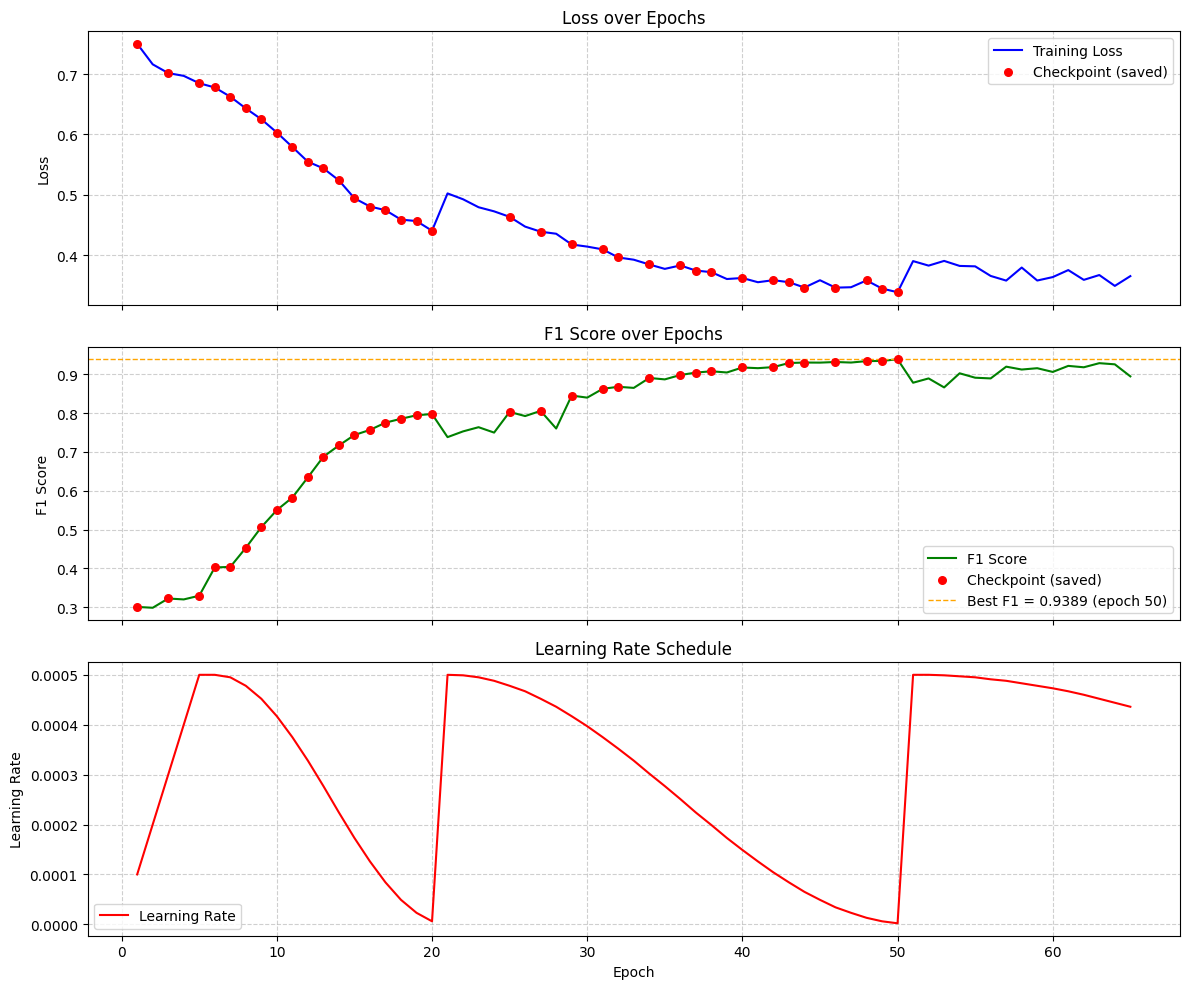

SWA F1: 0.9392
Final Model F1: 0.9385
Best Threshold: 0.845
Temperature: 0.65


In [2]:
import matplotlib.pyplot as plt
import numpy as np

final_info = {
    'swa_f1': 0.9392,
    'final_f1': 0.9385,
    'best_threshold': 0.845,
    'temperature': 0.65
}

epochs = history['epoch']
losses = history['loss']
f1_scores = history['f1']
lrs = history['lr']
saved_flags = history['saved']

saved_epochs = [epochs[i] for i, saved in enumerate(saved_flags) if saved]
best_f1_epoch = epochs[np.argmax(f1_scores)]
best_f1_value = max(f1_scores)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(epochs, losses, 'b-', linewidth=1.5, label='Training Loss')
axes[0].scatter(saved_epochs, [losses[i] for i, flag in enumerate(saved_flags) if flag],
                color='red', s=30, zorder=5, label='Checkpoint (saved)')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(epochs, f1_scores, 'g-', linewidth=1.5, label='F1 Score')
axes[1].scatter(saved_epochs, [f1_scores[i] for i, flag in enumerate(saved_flags) if flag],
                color='red', s=30, zorder=5, label='Checkpoint (saved)')
axes[1].axhline(y=best_f1_value, color='orange', linestyle='--', linewidth=1,
                label=f'Best F1 = {best_f1_value:.4f} (epoch {best_f1_epoch})')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score over Epochs')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(epochs, lrs, 'r-', linewidth=1.5, label='Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

if 'final_info' in locals():
    print(f"SWA F1: {final_info.get('swa_f1', 'N/A')}")
    print(f"Final Model F1: {final_info.get('final_f1', 'N/A')}")
    print(f"Best Threshold: {final_info.get('best_threshold', 'N/A')}")
    print(f"Temperature: {final_info.get('temperature', 'N/A')}")

# Инференс

In [ ]:
# Cell 8: Ensemble Inference + TTA [A100 — GPU batch FFT, bf16]

print(f"\n{'='*60}\nENSEMBLE INFERENCE\n{'='*60}")
models_info = []
for i, cfg in enumerate(Config.ENSEMBLE):
    p = os.path.join(Config.CHECKPOINT_DIR, f"model_v2_{i+1}.pth")
    if not os.path.exists(p): print(f"  Skip model {i+1}"); continue
    ck = torch.load(p, map_location=device, weights_only=False)
    mc = ck['cfg']
    fin = 6 if mc['freq']=='fft_phase' else 3
    m = DualStreamNetV2(3, fin, mc['ch'], Config.DROPOUT, double_blocks=Config.DOUBLE_BLOCKS).to(device)
    m.load_state_dict(ck['sd']); m.eval()
    fm = ck.get('fft_m'); fs = ck.get('fft_s')
    # Keep GPU copies for fast TTA FFT
    fm_gpu = fm.to(device) if fm is not None else None
    fs_gpu = fs.to(device) if fs is not None else None
    models_info.append({'m':m, 'cfg':mc, 'temp':ck.get('temp',1.), 'thr':ck.get('thr',.5),
                        'fm':fm_gpu, 'fs':fs_gpu, 'f1':ck.get('f1',0)})
    print(f"  Model {i+1}: F1={ck.get('f1',0):.4f} freq={mc['freq']}")

all_probs, all_ids = [], None
for mi in models_info:
    # Need CPU stats for DataLoader workers
    fm_cpu = mi['fm'].cpu() if mi['fm'] is not None else None
    fs_cpu = mi['fs'].cpu() if mi['fs'] is not None else None
    tl = DataLoader(TestDS(Config.TEST_IMG_DIR, get_tf('default',False),
                           mi['cfg']['freq'], fm_cpu, fs_cpu),
                    Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
    mp, ids = [], []
    fb = FREQ_BATCH[mi['cfg']['freq']]
    with torch.no_grad():
        for iid,img,frq in tqdm(tl, desc=f"Pred [{mi['cfg']['freq']}]"):
            img,frq = img.to(device),frq.to(device)
            T = mi['temp']
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p0 = torch.sigmoid(mi['m'](img,frq).squeeze(1)/T)
                # TTA hflip — GPU batch FFT (fast!)
                ih = torch.flip(img,[-1])
                p1 = torch.sigmoid(mi['m'](ih, fb(ih, mi['fm'], mi['fs'])).squeeze(1)/T)
                # TTA vflip
                iv = torch.flip(img,[-2])
                p2 = torch.sigmoid(mi['m'](iv, fb(iv, mi['fm'], mi['fs'])).squeeze(1)/T)
            mp.extend(((p0+p1+p2)/3).cpu().numpy())
            ids.extend(iid if isinstance(iid,list) else iid.tolist())
    if all_ids is None: all_ids = ids
    all_probs.append(np.array(mp))

ens = np.mean(all_probs, axis=0)
avg_thr = np.mean([m['thr'] for m in models_info])
preds = (ens > avg_thr).astype(int)

with open(Config.SUBMISSION_PATH, 'w') as f:
    for i, p in zip(all_ids, preds):
        f.write(f"{i},{p}\n")

nf = preds.sum()
print(f"\nSubmission saved: {Config.SUBMISSION_PATH}")
print(f"Threshold: {avg_thr:.3f}")
print(f"Real: {len(preds)-nf}, Fake: {nf}, Total: {len(preds)}")

# Создание submission (по одной модели)

Укажите свой путь для весов

In [ ]:
import os, sys, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

PROJECT = os.path.dirname(os.path.abspath(__file__))
TEST_DIR = os.path.join(PROJECT, "test_images", "test_images")
if not os.path.exists(TEST_DIR):
    TEST_DIR = os.path.join(PROJECT, "test_images")
CKPT = os.path.join(PROJECT, "model_v2_1.pth")
OUT = os.path.join(PROJECT, "submission.csv")

# === Model (same as training) ===
class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch//r, 8)
        self.fc = nn.Sequential(nn.Linear(ch, mid, bias=False), nn.ReLU(True), nn.Linear(mid, ch, bias=False))
    def forward(self, x):
        b, c = x.shape[:2]
        a = self.fc(F.adaptive_avg_pool2d(x,1).view(b,c))
        m = self.fc(F.adaptive_max_pool2d(x,1).view(b,c))
        return x * torch.sigmoid(a+m).view(b,c,1,1)

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(torch.cat([x.mean(1,keepdim=True), x.max(1,keepdim=True)[0]], 1)))

class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca, self.sa = ChannelAttention(ch, r), SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.c1 = nn.Conv2d(ic,oc,3,padding=1,bias=False); self.b1 = nn.BatchNorm2d(oc)
        self.c2 = nn.Conv2d(oc,oc,3,padding=1,bias=False); self.b2 = nn.BatchNorm2d(oc)
    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x)),True))),True)

class ResBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.conv = ConvBlock(ic, oc)
        self.skip = nn.Identity() if ic==oc else nn.Sequential(nn.Conv2d(ic,oc,1,bias=False), nn.BatchNorm2d(oc))
    def forward(self, x): return F.relu(self.conv(x) + self.skip(x), True)

class CrossFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gs = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
        self.gf = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
    def forward(self, s, f):
        sp, fp = F.adaptive_avg_pool2d(s,1).flatten(1), F.adaptive_avg_pool2d(f,1).flatten(1)
        c = torch.cat([sp,fp],1)
        gs, gf = self.gs(c).unsqueeze(-1).unsqueeze(-1), self.gf(c).unsqueeze(-1).unsqueeze(-1)
        return s*gs + f*(1-gs), f*gf + s*(1-gf)

def _make_stage_blocks(ic, oc, double=False):
    blocks = [ResBlock(ic, oc)]
    if double: blocks.append(ResBlock(oc, oc))
    blocks.append(CBAM(oc))
    return nn.Sequential(*blocks), nn.MaxPool2d(2)

class DualStreamNetV2(nn.Module):
    def __init__(self, spatial_in=3, freq_in=3, channels=None, dropout=0.3, double_blocks=False):
        super().__init__()
        ch = channels or [48,96,192,256,384]; db = double_blocks
        self.ss = nn.Sequential(nn.Conv2d(spatial_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        s1 = [ResBlock(ch[0],ch[0])];
        if db: s1.append(ResBlock(ch[0],ch[0]))
        s1 += [CBAM(ch[0]), nn.MaxPool2d(2)]; self.ss1 = nn.Sequential(*s1)
        self.ss2b, self.ss2p = _make_stage_blocks(ch[0],ch[1],db)
        self.ss3b, self.ss3p = _make_stage_blocks(ch[1],ch[2],db)
        self.ss4b, self.ss4p = _make_stage_blocks(ch[2],ch[3],db)
        s5 = [ResBlock(ch[3],ch[4])];
        if db: s5.append(ResBlock(ch[4],ch[4]))
        s5.append(CBAM(ch[4])); self.ss5 = nn.Sequential(*s5)
        self.fs = nn.Sequential(nn.Conv2d(freq_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        f1 = [ResBlock(ch[0],ch[0])];
        if db: f1.append(ResBlock(ch[0],ch[0]))
        f1 += [CBAM(ch[0]), nn.MaxPool2d(2)]; self.fs1 = nn.Sequential(*f1)
        self.fs2b, self.fs2p = _make_stage_blocks(ch[0],ch[1],db)
        self.fs3b, self.fs3p = _make_stage_blocks(ch[1],ch[2],db)
        self.fs4b, self.fs4p = _make_stage_blocks(ch[2],ch[3],db)
        f5 = [ResBlock(ch[3],ch[4])];
        if db: f5.append(ResBlock(ch[4],ch[4]))
        f5.append(CBAM(ch[4])); self.fs5 = nn.Sequential(*f5)
        self.cf2, self.cf3, self.cf4 = CrossFusion(ch[1]), CrossFusion(ch[2]), CrossFusion(ch[3])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Linear(ch[4]*2,512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(512,128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(128,1))
    def forward(self, si, fi):
        s, f = self.ss1(self.ss(si)), self.fs1(self.fs(fi))
        s, f = self.ss2b(s), self.fs2b(f); s, f = self.cf2(s,f); s, f = self.ss2p(s), self.fs2p(f)
        s, f = self.ss3b(s), self.fs3b(f); s, f = self.cf3(s,f); s, f = self.ss3p(s), self.fs3p(f)
        s, f = self.ss4b(s), self.fs4b(f); s, f = self.cf4(s,f); s, f = self.ss4p(s), self.fs4p(f)
        s, f = self.pool(self.ss5(s)).flatten(1), self.pool(self.fs5(f)).flatten(1)
        return self.clf(torch.cat([s,f],1))

# === FFT ===
def compute_fft(t, mean=None, std=None):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(t), dim=(-2,-1))))
    if mean is not None: return (lm - mean) / (std.clamp(min=0.01) + 1e-8)
    return lm / 12.

class TestDS(Dataset):
    def __init__(self, img_dir, tf, fm, fs):
        self.dir, self.tf, self.fm, self.fs = img_dir, tf, fm, fs
        self.ids = sorted(int(f.split('.')[0]) for f in os.listdir(img_dir) if f.endswith('.jpg'))
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
        except Exception:
            img = self.tf(Image.new("RGB", (256,256), (128,128,128)))
        return self.ids[i], img, compute_fft(img, self.fm, self.fs)

def compute_fft_batch(batch, mean, std):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(batch), dim=(-2,-1))))
    if mean is not None: return (lm - mean.unsqueeze(0)) / (std.clamp(min=0.01).unsqueeze(0) + 1e-8)
    return lm / 12.

# === Main ===
def main():
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {dev}")

    ck = torch.load(CKPT, map_location=dev, weights_only=False)
    cfg = ck['cfg']
    thr = ck.get('thr', 0.5)
    temp = ck.get('temp', 1.0)
    fft_m = ck.get('fft_m')
    fft_s = ck.get('fft_s')
    if fft_m is not None: fft_m_cpu, fft_s_cpu = fft_m.cpu(), fft_s.cpu()
    else: fft_m_cpu, fft_s_cpu = None, None

    model = DualStreamNetV2(3, 3, cfg['ch'], 0.3, double_blocks=True).to(dev)
    model.load_state_dict(ck['sd']); model.eval()
    print(f"Model: {sum(p.numel() for p in model.parameters()):,} params, F1={ck['f1']:.4f}, thr={thr:.3f}")

    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([.5]*3, [.5]*3)])
    ds = TestDS(TEST_DIR, tf, fft_m_cpu, fft_s_cpu)
    dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

    fft_m_gpu = fft_m.to(dev) if fft_m is not None else None
    fft_s_gpu = fft_s.to(dev) if fft_s is not None else None

    all_ids, all_probs = [], []
    with torch.no_grad():
        for iid, img, frq in tqdm(dl, desc="Predicting"):
            img, frq = img.to(dev), frq.to(dev)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                probs = torch.sigmoid(model(img, frq).squeeze(1) / temp)
            all_probs.extend(probs.cpu().float().numpy())
            all_ids.extend(iid if isinstance(iid, list) else iid.tolist())

    preds = (np.array(all_probs) > thr).astype(int)

    submission = pd.DataFrame({'id': all_ids, 'target_feature': preds})
    submission = submission.sort_values('id').reset_index(drop=True)
    submission.to_csv(OUT, index=False)

    print(f"\nSubmission saved: {OUT}")
    print(f"Format: id, target_feature (sorted by id)")
    print(f"Real: {(preds==0).sum()}, Fake: {(preds==1).sum()}, Total: {len(preds)}")
    print(submission.head(10))

if __name__ == "__main__":
    main()